In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers.experimental import preprocessing

import numpy as np
import os
import time
import matplotlib.pyplot as plt
!pip install Urduhack[tf-gpu]
import urduhack
urduhack.download()
import urduhack

     |████████████████████████████████| 112kB 23.5MB/s 
     |████████████████████████████████| 3.4MB 36.4MB/s 
     |████████████████████████████████| 454.3MB 40kB/s 
     |████████████████████████████████| 686kB 56.1MB/s 
  Found existing installation: tensorflow-datasets 4.0.1
    Uninstalling tensorflow-datasets-4.0.1:
      Successfully uninstalled tensorflow-datasets-4.0.1


90112/89078 [==============================] - 0s 0us/step


In [ ]:
path = '/content/drive/MyDrive/NLP/Notebooks/Final-Project/Dataset/Train/stories_dataset.txt'

# Preprocessing

In [ ]:
from urduhack.normalization import normalize
# Read, then decode for py2 compat.
text = open(path, 'rb').read().decode(encoding='utf-8')

normalized_text = normalize(text)

In [ ]:
from urduhack.preprocessing import normalize_whitespace,remove_punctuation,remove_accents,replace_urls,replace_emails,replace_numbers,replace_currency_symbols
preprocessed_text = normalize_whitespace(remove_accents(replace_urls(replace_emails(replace_numbers(replace_currency_symbols(normalized_text))))))

In [ ]:
print(preprocessed_text)

شہزاد بہت لاپرواہ اور کھیل کود میں مگن رہنے والا لڑکا تھا۔سارا دن فضول کھیلوں میں وقت ضائع کرتا تھا۔شہزاد کی ماں اس کے بچپن میں فوت ہو گئی تھی اور اس کا باپ صبح سویرے کھیت میں چلا جاتا اور رات کو دیر سے گھر واپس آتا تھا۔
جس وجہ سے شہزاد کی لاپروائی بہت بڑھ چکی تھی۔شہزاد کے باپ نے اس کو کئی مرتبہ سمجھایا کہ وقت ضائع کرنے کی بجائے اس کے ساتھ کھیت میں کام کروایا کرے یا پڑھنے جایا کرے لیکن شہزاد نے اپنی کسی عادت کو نہ بدلا۔پھر اس کے باپ نے ایک ترکیب سوچی اور شہزاد کو کہا کہ وہ صبح اس کے ساتھ کھیت میں چلے کیونکہ آج اس نے ایک خواب دیکھا ہے کہ ان کے کھیت میں جو سب سے اچھی بالی ہے اور ان کے بیج آئندہ سال بونے پر فصل کئی گنا زیادہ آئے گی۔
اس لئے وہ کھیت میں ساتھ چلے تاکہ جو بالی سب سے اچھی ہو وہ توڑ کر گھر لے اور سا بالی کے بیج نکال کر رکھ لیں گے تاکہ اگلے سال ان کو بو کر اپنی فصل کو کئی گنا بڑھا سکیں۔شہزاد نے فورا حامی بھر لی کہ وہ صبح کھیت میں ناک کی سیدھ میں جانا ہو گا اور بالی توڑنی ہو گی۔
پیچھے مڑ کر توڑنے سے موجودہ فصل بھی خراب ہو جائے گی۔
اب دونوں باپ بیٹا سو گئے اور صبح سویرے اٹھ کر کھی

In [ ]:
import re
new = re.sub('[A-Za-z0-9]'," ",preprocess_text)
new = re.sub('[,\.!#():?’؛]'," ",new)
new = re.sub('[۔]',' -',new)
new = re.sub('[…]',' ',new)
new = re.sub('[ٴ]',' ',new)
preprocessed_text= new

In [ ]:
# from urduhack import Pipeline
# nlp = Pipeline()
# doc = nlp(preprocess_text)
# for sentence in doc.sentences:
#         print(sentence.text)
# for word in sentence.words:
#         print(word.text)
# from urduhack.tokenization import sentence_tokenizer,word_tokenizer
# sentences = sentence_tokenizer(preprocessed_text)
# words = word_tokenizer(sentences)

In [ ]:
# Read, then decode for py2 compat.
# text = open(path, 'rb').read().decode(encoding='utf-8')
# length of text is the number of characters in it
text = preprocessed_text
print(f'Length of text: {len(text)} characters')

Length of text: 1147158 characters


In [ ]:
# Take a look at the first 250 characters in text
print(text[:250])


شہزاد بہت لاپرواہ اور کھیل کود میں مگن رہنے والا لڑکا تھا -سارا دن فضول کھیلوں میں وقت ضائع کرتا تھا -شہزاد کی ماں اس کے بچپن میں فوت ہو گئی تھی اور اس کا باپ صبح سویرے کھیت میں چلا جاتا اور رات کو دیر سے گھر واپس آتا تھا -
جس وجہ سے شہزاد کی لاپروائ


In [ ]:
# The unique characters in the file
vocab = sorted(set(text))
print(f'{len(vocab)} unique characters')

52 unique characters


In [ ]:
example_texts = ['abcdefg', 'xyz']

chars = tf.strings.unicode_split(example_texts, input_encoding='UTF-8')
chars

<tf.RaggedTensor [[b'a', b'b', b'c', b'd', b'e', b'f', b'g'], [b'x', b'y', b'z']]>

In [ ]:
ids_from_chars = preprocessing.StringLookup(
    vocabulary=list(vocab), mask_token=None)

In [ ]:
ids = ids_from_chars(chars)
ids

<tf.RaggedTensor [[31, 32, 33, 34, 35, 0, 36], [49, 50, 0]]>

In [ ]:
chars_from_ids = tf.keras.layers.experimental.preprocessing.StringLookup(
    vocabulary=ids_from_chars.get_vocabulary(), invert=True, mask_token=None)

In [ ]:
chars = chars_from_ids(ids)
chars

<tf.RaggedTensor [[b'a', b'b', b'c', b'd', b'e', b'[UNK]', b'g'], [b'x', b'y', b'[UNK]']]>

In [ ]:
tf.strings.reduce_join(chars, axis=-1).numpy()


array([b'abcde[UNK]g', b'xy[UNK]'], dtype=object)

In [ ]:
def text_from_ids(ids):
  return tf.strings.reduce_join(chars_from_ids(ids), axis=-1)

In [ ]:
all_ids = ids_from_chars(tf.strings.unicode_split(text, 'UTF-8'))
all_ids

<tf.Tensor: shape=(1133244,), dtype=int64, numpy=array([70, 94, 68, ..., 91, 58, 99])>

In [ ]:
ids_dataset = tf.data.Dataset.from_tensor_slices(all_ids)


In [ ]:
for ids in ids_dataset.take(10):
    print(chars_from_ids(ids).numpy().decode('utf-8'))

ش
ہ
ز
ا
د
 
ب
ہ
ت
 


In [ ]:
seq_length = 100
examples_per_epoch = len(text)//(seq_length+1)

In [ ]:
sequences = ids_dataset.batch(seq_length+1, drop_remainder=True)

for seq in sequences.take(1):
  print(chars_from_ids(seq))

tf.Tensor(
[b'\xd8\xb4' b'\xdb\x81' b'\xd8\xb2' b'\xd8\xa7' b'\xd8\xaf' b' '
 b'\xd8\xa8' b'\xdb\x81' b'\xd8\xaa' b' ' b'\xd9\x84' b'\xd8\xa7'
 b'\xd9\xbe' b'\xd8\xb1' b'\xd9\x88' b'\xd8\xa7' b'\xdb\x81' b' '
 b'\xd8\xa7' b'\xd9\x88' b'\xd8\xb1' b' ' b'\xda\xa9' b'\xda\xbe'
 b'\xdb\x8c' b'\xd9\x84' b' ' b'\xda\xa9' b'\xd9\x88' b'\xd8\xaf' b' '
 b'\xd9\x85' b'\xdb\x8c' b'\xda\xba' b' ' b'\xd9\x85' b'\xda\xaf'
 b'\xd9\x86' b' ' b'\xd8\xb1' b'\xdb\x81' b'\xd9\x86' b'\xdb\x92' b' '
 b'\xd9\x88' b'\xd8\xa7' b'\xd9\x84' b'\xd8\xa7' b' ' b'\xd9\x84'
 b'\xda\x91' b'\xda\xa9' b'\xd8\xa7' b' ' b'\xd8\xaa' b'\xda\xbe'
 b'\xd8\xa7' b'\xdb\x94' b'\xd8\xb3' b'\xd8\xa7' b'\xd8\xb1' b'\xd8\xa7'
 b' ' b'\xd8\xaf' b'\xd9\x86' b' ' b'\xd9\x81' b'\xd8\xb6' b'\xd9\x88'
 b'\xd9\x84' b' ' b'\xda\xa9' b'\xda\xbe' b'\xdb\x8c' b'\xd9\x84'
 b'\xd9\x88' b'\xda\xba' b' ' b'\xd9\x85' b'\xdb\x8c' b'\xda\xba' b' '
 b'\xd9\x88' b'\xd9\x82' b'\xd8\xaa' b' ' b'\xd8\xb6' b'\xd8\xa7'
 b'\xd8\xa6' b'\xd8\xb9' b' ' b'\xda\x

In [ ]:
for seq in sequences.take(5):
  print(text_from_ids(seq).numpy())

b'\xd8\xb4\xdb\x81\xd8\xb2\xd8\xa7\xd8\xaf \xd8\xa8\xdb\x81\xd8\xaa \xd9\x84\xd8\xa7\xd9\xbe\xd8\xb1\xd9\x88\xd8\xa7\xdb\x81 \xd8\xa7\xd9\x88\xd8\xb1 \xda\xa9\xda\xbe\xdb\x8c\xd9\x84 \xda\xa9\xd9\x88\xd8\xaf \xd9\x85\xdb\x8c\xda\xba \xd9\x85\xda\xaf\xd9\x86 \xd8\xb1\xdb\x81\xd9\x86\xdb\x92 \xd9\x88\xd8\xa7\xd9\x84\xd8\xa7 \xd9\x84\xda\x91\xda\xa9\xd8\xa7 \xd8\xaa\xda\xbe\xd8\xa7\xdb\x94\xd8\xb3\xd8\xa7\xd8\xb1\xd8\xa7 \xd8\xaf\xd9\x86 \xd9\x81\xd8\xb6\xd9\x88\xd9\x84 \xda\xa9\xda\xbe\xdb\x8c\xd9\x84\xd9\x88\xda\xba \xd9\x85\xdb\x8c\xda\xba \xd9\x88\xd9\x82\xd8\xaa \xd8\xb6\xd8\xa7\xd8\xa6\xd8\xb9 \xda\xa9\xd8\xb1\xd8\xaa\xd8\xa7 \xd8\xaa\xda\xbe\xd8\xa7\xdb\x94\xd8\xb4'
b'\xdb\x81\xd8\xb2\xd8\xa7\xd8\xaf \xda\xa9\xdb\x8c \xd9\x85\xd8\xa7\xda\xba \xd8\xa7\xd8\xb3 \xda\xa9\xdb\x92 \xd8\xa8\xda\x86\xd9\xbe\xd9\x86 \xd9\x85\xdb\x8c\xda\xba \xd9\x81\xd9\x88\xd8\xaa \xdb\x81\xd9\x88 \xda\xaf\xd8\xa6\xdb\x8c \xd8\xaa\xda\xbe\xdb\x8c \xd8\xa7\xd9\x88\xd8\xb1 \xd8\xa7\xd8\xb3 \xda\xa9\xd8\xa7 \

In [ ]:
def split_input_target(sequence):
    input_text = sequence[:-1]
    target_text = sequence[1:]
    return input_text, target_text

In [ ]:
split_input_target(list("Tensorflow"))


(['T', 'e', 'n', 's', 'o', 'r', 'f', 'l', 'o'],
 ['e', 'n', 's', 'o', 'r', 'f', 'l', 'o', 'w'])

In [ ]:
dataset = sequences.map(split_input_target)


In [ ]:
for input_example, target_example in dataset.take(1):
    print("Input :", text_from_ids(input_example).numpy())
    print("Target:", text_from_ids(target_example).numpy())

Input : b'\xd8\xb4\xdb\x81\xd8\xb2\xd8\xa7\xd8\xaf \xd8\xa8\xdb\x81\xd8\xaa \xd9\x84\xd8\xa7\xd9\xbe\xd8\xb1\xd9\x88\xd8\xa7\xdb\x81 \xd8\xa7\xd9\x88\xd8\xb1 \xda\xa9\xda\xbe\xdb\x8c\xd9\x84 \xda\xa9\xd9\x88\xd8\xaf \xd9\x85\xdb\x8c\xda\xba \xd9\x85\xda\xaf\xd9\x86 \xd8\xb1\xdb\x81\xd9\x86\xdb\x92 \xd9\x88\xd8\xa7\xd9\x84\xd8\xa7 \xd9\x84\xda\x91\xda\xa9\xd8\xa7 \xd8\xaa\xda\xbe\xd8\xa7\xdb\x94\xd8\xb3\xd8\xa7\xd8\xb1\xd8\xa7 \xd8\xaf\xd9\x86 \xd9\x81\xd8\xb6\xd9\x88\xd9\x84 \xda\xa9\xda\xbe\xdb\x8c\xd9\x84\xd9\x88\xda\xba \xd9\x85\xdb\x8c\xda\xba \xd9\x88\xd9\x82\xd8\xaa \xd8\xb6\xd8\xa7\xd8\xa6\xd8\xb9 \xda\xa9\xd8\xb1\xd8\xaa\xd8\xa7 \xd8\xaa\xda\xbe\xd8\xa7\xdb\x94'
Target: b'\xdb\x81\xd8\xb2\xd8\xa7\xd8\xaf \xd8\xa8\xdb\x81\xd8\xaa \xd9\x84\xd8\xa7\xd9\xbe\xd8\xb1\xd9\x88\xd8\xa7\xdb\x81 \xd8\xa7\xd9\x88\xd8\xb1 \xda\xa9\xda\xbe\xdb\x8c\xd9\x84 \xda\xa9\xd9\x88\xd8\xaf \xd9\x85\xdb\x8c\xda\xba \xd9\x85\xda\xaf\xd9\x86 \xd8\xb1\xdb\x81\xd9\x86\xdb\x92 \xd9\x88\xd8\xa7\xd9\x84\xd8\x

In [ ]:
# Batch size
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
# (TF data is designed to work with possibly infinite sequences,
# so it doesn't attempt to shuffle the entire sequence in memory. Instead,
# it maintains a buffer in which it shuffles elements).
BUFFER_SIZE = 10000

dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.experimental.AUTOTUNE))

dataset

<PrefetchDataset shapes: ((64, 100), (64, 100)), types: (tf.int64, tf.int64)>

In [ ]:
# Length of the vocabulary in chars
vocab_size = len(vocab)

# The embedding dimension
embedding_dim = 256

# Number of RNN units
rnn_units = 1024

In [ ]:
class MyModel(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, rnn_units):
    super().__init__(self)
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(rnn_units,
                                   return_sequences=True,
                                   return_state=True)
    self.dense = tf.keras.layers.Dense(vocab_size)

  def call(self, inputs, states=None, return_state=False, training=False):
    x = inputs
    x = self.embedding(x, training=training)
    if states is None:
      states = self.gru.get_initial_state(x)
    x, states = self.gru(x, initial_state=states, training=training)
    x = self.dense(x, training=training)

    if return_state:
      return x, states
    else:
      return x

In [ ]:
model = MyModel(
    # Be sure the vocabulary size matches the `StringLookup` layers.
    vocab_size=len(ids_from_chars.get_vocabulary()),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units)

In [ ]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

(64, 100, 103) # (batch_size, sequence_length, vocab_size)


In [ ]:
model.summary()


Model: "my_model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_14 (Embedding)     multiple                  26368     
_________________________________________________________________
gru_2 (GRU)                  multiple                  3938304   
_________________________________________________________________
dense_10 (Dense)             multiple                  105575    
Total params: 4,070,247
Trainable params: 4,070,247
Non-trainable params: 0
_________________________________________________________________


In [ ]:
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices, axis=-1).numpy()

In [ ]:
sampled_indices


array([ 12,  51,  69,  45,  33,  31,  87,  90,  42,  53,  23,  99,  37,
        47,  34,  46,  60,  24,  59,  38,  79,  59,  26,  28,  63,  71,
        82,  33,  66,  63,  88,  16,  37,  83,  37, 101,  69,  53,  40,
        53,  28,  33,   4,  80,  30,  37,  56,  68,  21,  82,  46,  97,
       102,  14,  47,  63,  31,  35,  70,  42, 100,  93,  62,  52,  82,
        63,  11,  38,  23,  46,  43,   5,  28,  71,  84,   4,   0,  74,
        52,  87,  35,  23,  38,  68,  29,  33,  41,  16,  29,  38,  87,
        84,  93,  27,  17,  15,  24,  49,  48,   3])

In [ ]:
print("Input:\n", text_from_ids(input_example_batch[0]).numpy())
print()
print("Next Char Predictions:\n", text_from_ids(sampled_indices).numpy())

Input:
 b' \xda\x86\xdb\x8c\xd8\xb2\xdb\x8c\xda\xba \xd8\xaf\xdb\x8c\xda\xa9\xda\xbe \xda\xa9\xd8\xb1 \xd9\xb9\xd9\x86\xda\xa9\xd9\x88 \xd8\xae\xd9\x88\xd8\xa8 \xd9\x84\xd9\x84\xda\x86\xd8\xa7 \xdb\x8c\xd8\xa7 \xd8\xa7\xd8\xb3 \xd9\x86\xdb\x92 \xd8\xaa\xdb\x81\xdb\x8c\xdb\x81 \xda\xa9\xd8\xb1 \xd9\x84\xdb\x8c\xd8\xa7 \xda\xa9\xdb\x81 \xd9\x88\xdb\x81 \xd8\xa8\xda\xbe\xdb\x8c \xd8\xb1\xd9\x88\xd8\xb2\xdb\x81 \xd8\xb1\xda\xa9\xda\xbe\xdb\x92 \xda\xaf\xd8\xa7 \xd8\xa7\xda\xaf\xd9\x84\xdb\x92 \xd8\xaf\xd9\x86 \xdb\x81\xdb\x8c \xd8\xa7\xd8\xb3 \xd9\x86\xdb\x92 \xd9\x85\xd8\xa7\xd9\x85\xd8\xa7 \xd8\xb3\xdb\x92 \xda\xa9\xdb\x81'

Next Char Predictions:
 b'5\xd8\x9b\xd8\xb3sca\xda\x88\xda\xa9o\xd8\xa1H\xdb\x94hudt\xd8\xaaI\xd8\xa8i\xd9\x84\xd8\xa8MR\xd8\xad\xd8\xb5\xd9\x88c\xd8\xb0\xd8\xad\xda\x919h\xd9\xb4h\xdb\xb4\xd8\xb3\xd8\xa1m\xd8\xa1Rc(\xd9\x85Wh\xd8\xa4\xd8\xb2D\xd9\x88t\xdb\x92\xdb\xb97u\xd8\xadae\xd8\xb4o\xdb\xb1\xda\xbe\xd8\xac\xd8\x9f\xd9\x88\xd8\xad4iHtp)R\xd8\xb5\xd9\xb9([UNK]\xd

In [ ]:
loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True)


In [ ]:
example_batch_loss = loss(target_example_batch, example_batch_predictions)
mean_loss = example_batch_loss.numpy().mean()
print("Prediction shape: ", example_batch_predictions.shape, " # (batch_size, sequence_length, vocab_size)")
print("Mean loss:        ", mean_loss)

Prediction shape:  (64, 100, 103)  # (batch_size, sequence_length, vocab_size)
Mean loss:         4.63606


In [ ]:
tf.exp(mean_loss).numpy()


103.13721

In [ ]:
model.compile(optimizer='adam', loss=loss)


In [ ]:
# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)

In [ ]:
EPOCHS = 30


In [ ]:
history = model.fit(dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])


Epoch 1/30
175/175 [==============================] - 11s 50ms/step - loss: 2.6795
Epoch 2/30
 12/175 [=>............................] - ETA: 8s - loss: 2.2288

KeyboardInterrupt: ignored

In [ ]:
class OneStep(tf.keras.Model):
  def __init__(self, model, chars_from_ids, ids_from_chars, temperature=1.0):
    super().__init__()
    self.temperature = temperature
    self.model = model
    self.chars_from_ids = chars_from_ids
    self.ids_from_chars = ids_from_chars

    # Create a mask to prevent "[UNK]" from being generated.
    skip_ids = self.ids_from_chars(['[UNK]'])[:, None]
    sparse_mask = tf.SparseTensor(
        # Put a -inf at each bad index.
        values=[-float('inf')]*len(skip_ids),
        indices=skip_ids,
        # Match the shape to the vocabulary
        dense_shape=[len(ids_from_chars.get_vocabulary())])
    self.prediction_mask = tf.sparse.to_dense(sparse_mask)

  @tf.function
  def generate_one_step(self, inputs, states=None):
    # Convert strings to token IDs.
    input_chars = tf.strings.unicode_split(inputs, 'UTF-8')
    input_ids = self.ids_from_chars(input_chars).to_tensor()

    # Run the model.
    # predicted_logits.shape is [batch, char, next_char_logits]
    predicted_logits, states = self.model(inputs=input_ids, states=states,
                                          return_state=True)
    # Only use the last prediction.
    predicted_logits = predicted_logits[:, -1, :]
    predicted_logits = predicted_logits/self.temperature
    # Apply the prediction mask: prevent "[UNK]" from being generated.
    predicted_logits = predicted_logits + self.prediction_mask

    # Sample the output logits to generate token IDs.
    predicted_ids = tf.random.categorical(predicted_logits, num_samples=1)
    predicted_ids = tf.squeeze(predicted_ids, axis=-1)

    # Convert from token ids to characters
    predicted_chars = self.chars_from_ids(predicted_ids)

    # Return the characters and model state.
    return predicted_chars, states

In [ ]:
one_step_model = OneStep(model, chars_from_ids, ids_from_chars)

In [ ]:
start = time.time()
states = None
next_char = tf.constant(['کامیاب ہو'])
result = [next_char]

for n in range(1000):
  next_char, states = one_step_model.generate_one_step(next_char, states=states)
  result.append(next_char)

result = tf.strings.join(result)
end = time.time()
print(result[0].numpy().decode('utf-8'), '\n\n' + '_'*80)
print('\nRun time:', end - start)

# Text Generation Using RNN+LSTM

In [ ]:
# The unique characters in the file
vocab = sorted(set(preprocessed_text))
print(f'{len(vocab)} unique characters')

52 unique characters


In [ ]:
# Map characters to their indices in vocabulary.
char2index = {char: index for index, char in enumerate(vocab)}

print('{')
for char, _ in zip(char2index, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2index[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '-' :   2,
  '؟' :   3,
  'ء' :   4,
  'آ' :   5,
  'أ' :   6,
  'ؤ' :   7,
  'ئ' :   8,
  'ا' :   9,
  'ب' :  10,
  'ت' :  11,
  'ث' :  12,
  'ج' :  13,
  'ح' :  14,
  'خ' :  15,
  'د' :  16,
  'ذ' :  17,
  'ر' :  18,
  'ز' :  19,
  ...
}


In [ ]:
# Map character indices to characters from vacabulary.
index2char = np.array(vocab)
print(index2char)

['\n' ' ' '-' '؟' 'ء' 'آ' 'أ' 'ؤ' 'ئ' 'ا' 'ب' 'ت' 'ث' 'ج' 'ح' 'خ' 'د' 'ذ'
 'ر' 'ز' 'س' 'ش' 'ص' 'ض' 'ط' 'ظ' 'ع' 'غ' 'ف' 'ق' 'ل' 'م' 'ن' 'و' 'ٹ' 'پ'
 'چ' 'ڈ' 'ڑ' 'ژ' 'ک' 'گ' 'ں' 'ھ' 'ہ' 'ۃ' 'ی' 'ے' 'ۓ' '۱' '۴' '۹']


In [ ]:
# Convert chars in text to indices.
text_as_int = np.array([char2index[char] for char in new])

print('text_as_int length: {}'.format(len(text_as_int)))
print('{} --> {}'.format(repr(text[:15]), repr(text_as_int[:15])))

text_as_int length: 1147158
'شہزاد بہت لاپرو' --> array([21, 44, 19,  9, 16,  1, 10, 44, 11,  1, 30,  9, 35, 18, 33])


In [ ]:
# The maximum length sentence we want for a single input in characters.
sequence_length = 100
examples_per_epoch = len(new) // (sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

examples_per_epoch: 11358


In [ ]:
# Create training dataset.
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

for char in char_dataset.take(5):
    print(index2char[char.numpy()])

ش
ہ
ز
ا
د


In [ ]:
# Generate batched sequences out of the char_dataset.
sequences = char_dataset.batch(sequence_length + 1, drop_remainder=True)

# Sequences size is the same as examples_per_epoch.
print('Sequences count: {}'.format(len(list(sequences.as_numpy_iterator()))));
print()

# Sequences examples.
for item in sequences.take(5):
    print(repr(''.join(index2char[item.numpy()])))

Sequences count: 11358

'شہزاد بہت لاپرواہ اور کھیل کود میں مگن رہنے والا لڑکا تھا -سارا دن فضول کھیلوں میں وقت ضائع کرتا تھا '
'-شہزاد کی ماں اس کے بچپن میں فوت ہو گئی تھی اور اس کا باپ صبح سویرے کھیت میں چلا جاتا اور رات کو دیر '
'سے گھر واپس آتا تھا -\nجس وجہ سے شہزاد کی لاپروائی بہت بڑھ چکی تھی -شہزاد کے باپ نے اس کو کئی مرتبہ سم'
'جھایا کہ وقت ضائع کرنے کی بجائے اس کے ساتھ کھیت میں کام کروایا کرے یا پڑھنے جایا کرے لیکن شہزاد نے اپ'
'نی کسی عادت کو نہ بدلا -پھر اس کے باپ نے ایک ترکیب سوچی اور شہزاد کو کہا کہ وہ صبح اس کے ساتھ کھیت می'


In [ ]:
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

In [ ]:
dataset = sequences.map(split_input_target)

# Dataset size is the same as examples_per_epoch.
# But each element of a sequence is now has length of `sequence_length`
# and not `sequence_length + 1`.
print('dataset size: {}'.format(len(list(dataset.as_numpy_iterator()))))

dataset size: 11358


In [ ]:
for input_example, target_example in dataset.take(1):
    print('Input sequence size:', repr(len(input_example.numpy())))
    print('Target sequence size:', repr(len(target_example.numpy())))
    print()
    print('Input:', repr(''.join(index2char[input_example.numpy()])))
    print('Target:', repr(''.join(index2char[target_example.numpy()])))

Input sequence size: 100
Target sequence size: 100

Input: 'شہزاد بہت لاپرواہ اور کھیل کود میں مگن رہنے والا لڑکا تھا -سارا دن فضول کھیلوں میں وقت ضائع کرتا تھا'
Target: 'ہزاد بہت لاپرواہ اور کھیل کود میں مگن رہنے والا لڑکا تھا -سارا دن فضول کھیلوں میں وقت ضائع کرتا تھا '


In [ ]:
for i, (input_idx, target_idx) in enumerate(zip(input_example[:5], target_example[:5])):
    print('Step {:2d}'.format(i))
    print('  input: {} ({:s})'.format(input_idx, repr(index2char[input_idx])))
    print('  expected output: {} ({:s})'.format(target_idx, repr(index2char[target_idx])))

Step  0
  input: 21 ('ش')
  expected output: 44 ('ہ')
Step  1
  input: 44 ('ہ')
  expected output: 19 ('ز')
Step  2
  input: 19 ('ز')
  expected output: 9 ('ا')
Step  3
  input: 9 ('ا')
  expected output: 16 ('د')
Step  4
  input: 16 ('د')
  expected output: 1 (' ')


In [ ]:
# Batch size.
BATCH_SIZE = 64
# Buffer size to shuffle the dataset (TF data is designed to work
# with possibly infinite sequences, so it doesn't attempt to shuffle
# the entire sequence in memory. Instead, it maintains a buffer in
# which it shuffles elements).
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<BatchDataset shapes: ((64, 100), (64, 100)), types: (tf.int64, tf.int64)>

In [ ]:
print('Batched dataset size: {}'.format(len(list(dataset.as_numpy_iterator()))))

Batched dataset size: 177


In [ ]:
for input_text, target_text in dataset.take(1):
    print('1st batch: input_text:', input_text)
    print()
    print('1st batch: target_text:', target_text)

1st batch: input_text: tf.Tensor(
[[32  9 18 ... 44 33 18]
 [ 1 36 30 ... 10 30  9]
 [ 9  1  1 ... 31 41 18]
 ...
 [ 9 33 18 ... 11 43  9]
 [ 1 40 18 ...  9  8 46]
 [33 18 36 ...  2  0 14]], shape=(64, 100), dtype=int64)

1st batch: target_text: tf.Tensor(
[[ 9 18  9 ... 33 18 44]
 [36 30 46 ... 30  9  1]
 [ 1  1 31 ... 41 18  1]
 ...
 [33 18  1 ... 43  9  1]
 [40 18 11 ...  8 46  1]
 [18 36 46 ...  0 14  9]], shape=(64, 100), dtype=int64)


In [ ]:
# Let's do a quick detour and see how Embeding layer works.
# It takes several char indices sequences (batch) as an input.
# It encodes every character of every sequence to a vector of tmp_embeding_size length.
tmp_vocab_size = 10
tmp_embeding_size = 5
tmp_input_length = 8
tmp_batch_size = 2

tmp_model = tf.keras.models.Sequential()
tmp_model.add(tf.keras.layers.Embedding(
  input_dim=tmp_vocab_size,
  output_dim=tmp_embeding_size,
  input_length=tmp_input_length
))
# The model will take as input an integer matrix of size (batch, input_length).
# The largest integer (i.e. word index) in the input should be no larger than 9 (tmp_vocab_size).
# Now model.output_shape == (None, 10, 64), where None is the batch dimension.
tmp_input_array = np.random.randint(
  low=0,
  high=tmp_vocab_size,
  size=(tmp_batch_size, tmp_input_length)
)
tmp_model.compile('rmsprop', 'mse')
tmp_output_array = tmp_model.predict(tmp_input_array)

print('tmp_input_array shape:', tmp_input_array.shape)
print('tmp_input_array:')
print(tmp_input_array)
print()
print('tmp_output_array shape:', tmp_output_array.shape)
print('tmp_output_array:')
print(tmp_output_array)

tmp_input_array shape: (2, 8)
tmp_input_array:
[[4 9 4 6 8 1 1 8]
 [6 2 1 4 5 7 2 2]]

tmp_output_array shape: (2, 8, 5)
tmp_output_array:
[[[-2.05048565e-02  3.36754434e-02  1.73305012e-02  3.74779217e-02
   -9.24923271e-03]
  [-2.18732487e-02  1.16641745e-02 -1.83869116e-02 -3.23637277e-02
    1.40185468e-02]
  [-2.05048565e-02  3.36754434e-02  1.73305012e-02  3.74779217e-02
   -9.24923271e-03]
  [ 2.20706575e-02 -4.52500843e-02  1.28465779e-02  4.97905351e-02
    3.69267724e-02]
  [-1.17441639e-02  3.12888958e-02 -3.19891572e-02 -1.50110610e-02
   -2.25613955e-02]
  [-2.42629778e-02  4.31682728e-02  8.34537670e-03  4.13767993e-05
   -4.42871451e-02]
  [-2.42629778e-02  4.31682728e-02  8.34537670e-03  4.13767993e-05
   -4.42871451e-02]
  [-1.17441639e-02  3.12888958e-02 -3.19891572e-02 -1.50110610e-02
   -2.25613955e-02]]

 [[ 2.20706575e-02 -4.52500843e-02  1.28465779e-02  4.97905351e-02
    3.69267724e-02]
  [ 4.91256006e-02 -8.43509287e-03 -3.39302644e-02  4.87425588e-02
    3.425

In [ ]:
# Length of the vocabulary in chars.
vocab_size = len(vocab)

# The embedding dimension.
embedding_dim = 256

# Number of RNN units.
rnn_units = 1024

In [ ]:
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      batch_input_shape=[batch_size, None]
    ))

    model.add(tf.keras.layers.LSTM(
      units=rnn_units,
      return_sequences=True,
      stateful=True,
      recurrent_initializer=tf.keras.initializers.GlorotNormal()
    ))

    model.add(tf.keras.layers.Dense(vocab_size))

    return model

In [ ]:
model = build_model(vocab_size, embedding_dim, rnn_units, BATCH_SIZE)

In [ ]:
model.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_12 (Embedding)     (64, None, 256)           13312     
_________________________________________________________________
lstm_6 (LSTM)                (64, None, 1024)          5246976   
_________________________________________________________________
dense_8 (Dense)              (64, None, 52)            53300     
Total params: 5,313,588
Trainable params: 5,313,588
Non-trainable params: 0
_________________________________________________________________


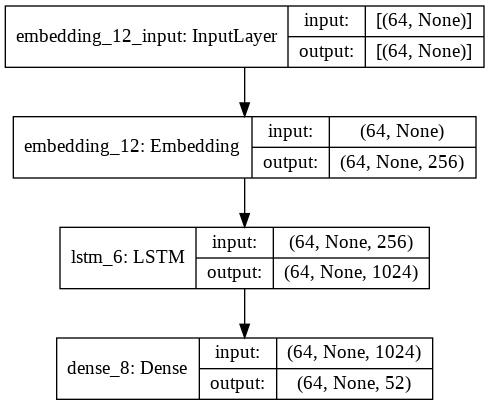

In [ ]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
)

In [ ]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

(64, 100, 52) # (batch_size, sequence_length, vocab_size)


In [ ]:
print('Prediction for the 1st letter of the batch 1st sequense:')
print(example_batch_predictions[0][0])

Prediction for the 1st letter of the batch 1st sequense:
tf.Tensor(
[ 4.4389423e-03  1.1700188e-03 -9.5880893e-04 -3.8587670e-03
 -1.1609279e-03 -1.0390267e-03 -2.5443742e-03 -1.3322555e-03
  3.4703184e-03  1.0581155e-03 -4.5755105e-03  2.4932693e-03
 -1.0981756e-03  9.1887335e-04  5.6364061e-03  3.1385575e-03
 -4.4154003e-03  3.2965452e-03  1.0706687e-03 -1.4092645e-03
 -1.4812083e-03 -2.0572401e-03 -2.4842098e-03 -3.3157363e-03
 -7.4242952e-04 -4.1941702e-03  8.6411368e-05  3.7197794e-03
  2.5824388e-03  2.6970040e-03  4.5704041e-03  2.1002635e-03
 -5.6883029e-05 -2.0004867e-03  1.2032935e-05  2.1965636e-03
 -4.0555666e-03 -2.5740773e-03  2.8263438e-03  4.9730605e-03
  7.0677111e-03  1.1360273e-03  9.4478019e-05  1.4893126e-03
  2.7633447e-03 -9.6103223e-04 -8.9636416e-04 -5.9909082e-04
 -7.8742867e-03 -3.1005563e-03 -2.8684933e-03 -3.6665350e-03], shape=(52,), dtype=float32)


In [ ]:
sampled_indices = tf.random.categorical(
    logits=example_batch_predictions[0],
    num_samples=1
)

sampled_indices.shape

TensorShape([100, 1])

In [ ]:
sampled_indices = tf.squeeze(
    input=sampled_indices,
    axis=-1
).numpy()

sampled_indices.shape

(100,)

In [ ]:
sampled_indices

array([47, 15, 14, 37, 21,  6, 30, 36,  6, 31, 36, 26, 50, 23, 31, 42, 15,
       35,  6,  4,  3, 51, 27, 14, 35, 51, 45, 18,  9, 44, 26,  5, 35, 25,
       17,  2, 40, 46, 51,  8,  0, 44, 10, 38, 36,  6, 21, 18, 34, 11, 27,
        8, 18, 45, 20, 39, 32, 35, 28, 47, 29, 36,  6, 36, 23,  9, 35, 20,
       36, 21, 34, 28, 46, 36, 39,  3, 21,  7, 32, 51, 13, 47,  4,  2, 28,
       22, 42, 49,  8, 43, 30, 44, 51, 20, 51,  8, 50,  0, 47,  0])

In [ ]:
print('Input:\n', repr(''.join(index2char[input_example_batch[0]])))
print()
print('Next char prediction:\n', repr(''.join(index2char[sampled_indices])))

Input:
 'ر حوصلے کے ساتھ دیتا تھا -\nاسے یقین تھا کہ کبھی نہ کبھی اس کی امیدیں ضرور بر آئیں گی اور پھر امید تو'

Next char prediction:
 'ےخحڈشألچأمچع۴ضمںخپأء؟۹غحپ۹ۃراہعآپظذ-کی۹ئ\nہبڑچأشرٹتغئرۃسژنپفےقچأچضاپسچشٹفیچژ؟شؤن۹جےء-فصں۱ئھلہ۹س۹ئ۴\nے\n'


In [ ]:
for i, (input_idx, sample_idx) in enumerate(zip(input_example_batch[0][:5], sampled_indices[:5])):
    print('Prediction {:2d}'.format(i))
    print('  input: {} ({:s})'.format(input_idx, repr(index2char[input_idx])))
    print('  next predicted: {} ({:s})'.format(target_idx, repr(index2char[sample_idx])))

Prediction  0
  input: 18 ('ر')
  next predicted: 1 ('ے')
Prediction  1
  input: 1 (' ')
  next predicted: 1 ('خ')
Prediction  2
  input: 14 ('ح')
  next predicted: 1 ('ح')
Prediction  3
  input: 33 ('و')
  next predicted: 1 ('ڈ')
Prediction  4
  input: 22 ('ص')
  next predicted: 1 ('ش')


In [ ]:
# An objective function.
# The function is any callable with the signature scalar_loss = fn(y_true, y_pred).
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
      y_true=labels,
      y_pred=logits,
      from_logits=True
    )

example_batch_loss = loss(target_example_batch, example_batch_predictions)

print("Prediction shape: ", example_batch_predictions.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (64, 100, 52)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       3.9520547


In [ ]:
adam_optimizer = tf.keras.optimizers.Adam() #learning_rate=0.001
model.compile(
    optimizer=adam_optimizer,
    loss=loss
)

In [ ]:
# Directory where the checkpoints will be saved.
checkpoint_dir = 'tmp/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt_{epoch}')

checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True
)

In [ ]:
EPOCHS=30

In [ ]:
history = model.fit(
  x=dataset,
  epochs=EPOCHS,
  callbacks=[
    checkpoint_callback
  ]
)

Epoch 1/30
177/177 [==============================] - 13s 62ms/step - loss: 2.5114
Epoch 2/30
177/177 [==============================] - 12s 62ms/step - loss: 1.9556
Epoch 3/30
177/177 [==============================] - 12s 62ms/step - loss: 1.7165
Epoch 4/30
177/177 [==============================] - 12s 62ms/step - loss: 1.5807
Epoch 5/30
177/177 [==============================] - 12s 62ms/step - loss: 1.4926
Epoch 6/30
177/177 [==============================] - 12s 63ms/step - loss: 1.4280
Epoch 7/30
177/177 [==============================] - 12s 63ms/step - loss: 1.3752
Epoch 8/30
177/177 [==============================] - 12s 63ms/step - loss: 1.3282
Epoch 9/30
177/177 [==============================] - 12s 63ms/step - loss: 1.2845
Epoch 10/30
177/177 [==============================] - 12s 64ms/step - loss: 1.2398
Epoch 11/30
177/177 [==============================] - 12s 64ms/step - loss: 1.1968
Epoch 12/30
177/177 [==============================] - 12s 64ms/step - loss: 1.1503
E

In [ ]:
def render_training_history(training_history):
    loss = training_history.history['loss']
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(loss, label='Training set')
    plt.legend()
    plt.grid(linestyle='--', linewidth=1, alpha=0.5)
    plt.show()

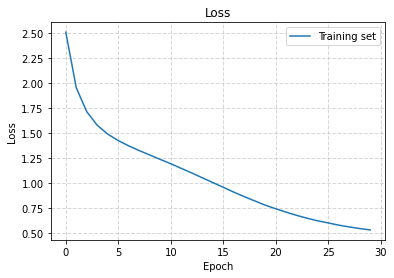

In [ ]:
render_training_history(history)

In [ ]:
tf.train.latest_checkpoint(checkpoint_dir)

'tmp/checkpoints/ckpt_30'

In [ ]:
simplified_batch_size = 1

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)

model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))

model.build(tf.TensorShape([simplified_batch_size, None]))

In [ ]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_13 (Embedding)     (1, None, 256)            13312     
_________________________________________________________________
lstm_7 (LSTM)                (1, None, 1024)           5246976   
_________________________________________________________________
dense_9 (Dense)              (1, None, 52)             53300     
Total params: 5,313,588
Trainable params: 5,313,588
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# num_generate
# - number of characters to generate.
#
# temperature
# - Low temperatures results in more predictable text.
# - Higher temperatures results in more surprising text.
# - Experiment to find the best setting.
def generate_text(model, start_string, num_generate = 1000, temperature=1.0):
    # Evaluation step (generating text using the learned model)

    # Converting our start string to numbers (vectorizing).
    input_indices = [char2index[s] for s in start_string]
    input_indices = tf.expand_dims(input_indices, 0)

    # Empty string to store our results.
    text_generated = []

    # Here batch size == 1.
    model.reset_states()
    for char_index in range(num_generate):
        predictions = model(input_indices)
        # remove the batch dimension
        predictions = tf.squeeze(predictions, 0)

        # Using a categorical distribution to predict the character returned by the model.
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(
        predictions,
        num_samples=1
        )[-1,0].numpy()

        # We pass the predicted character as the next input to the model
        # along with the previous hidden state.
        input_indices = tf.expand_dims([predicted_id], 0)

        text_generated.append(index2char[predicted_id])

    return (start_string + ''.join(text_generated))

In [ ]:
# Generate the text with default temperature (1.0).
print(generate_text(model, start_string=u"محبت",num_generate=1000))

محبتی سے پہلے ہی لگتا تھا -پھر اچانک میرا نام سنا ہو - پھروں کے منہ سے قیمتی چھوٹے سے پیٹ پرانے کا عذر تب جارہاہے -
چچا چمن نے خوشگوار حکمت سے ہمیں فائدہ پہنچایا تو کہیں کل کی پیٹھ پر سکون نہیں  -توبنٹھلی گئیں اور پانچواں چینی بھائی کی پریشانی دیکھ کر مای خوش اور مہربانیتے  -
ایک روز ملک اپنی جماعت سے نکالا تو بالے نے پوچھا -
 سا پیچھے ان تینوں کے ساتھ تمہیں تجربے کھوپڑی نے اسے گروہ کافی حد تک گند اللہ ہے اپنے کھیتوں اور برائی کروں گا وہ صرف چو یں میں آفس میں پھنس گیا اور آخر معاف کر دی  -اس دوران کا کار آپ کا دینھ کام کرنے اور معذوئی زندگی کے کتابوں کا تحریک پتہ تھا کہ نزی خریدی چور کو اسکا ذکر پریعام لگتا تھا اور اب جن کی سوچ سمجھ تھی اور اب وہ بچہ چیز کھیلنے کی ضرورت نہیں -
دونوں تیار ہو گی -
 کس وقت آٹ کو پیر کباڑی کی دنیا میں جانے لگی  -اسے جانوروں کی برائی کرنے لگا -میں نے کس طرح سے بھی خیال نکالا ہوا بولا- امی حضور جب میں اسکول کی خاتون تھی کہ اسے کسی دوست یا رشتے دار کے ہاتھوں پر فٹوخت کے چھلانگ لگائی اور لوگوں نے روین سے بیٹھ گیا- انہیں روز محض یہ کرتے ہوئے سمجھائی کہ ناصر اتن